# SOEN 471 - SmartCart Assignment Notebook

## Part 1 - Data PreProcessing

In [17]:
# Load data
import pandas as pd

user_data = pd.read_csv('data/ecommerce_user_data.csv')
product_data = pd.read_csv('data/product_details.csv')

print(user_data.head())
print(product_data.head())

  UserID ProductID  Rating   Timestamp  Category
0   U000     P0009       5  2024-09-08     Books
1   U000     P0020       1  2024-09-02      Home
2   U000     P0012       4  2024-10-18     Books
3   U000     P0013       1  2024-09-18  Clothing
4   U000     P0070       4  2024-09-16      Toys
  ProductID      ProductName     Category
0     P0000      Toys Item 0     Clothing
1     P0001  Clothing Item 1  Electronics
2     P0002     Books Item 2  Electronics
3     P0003  Clothing Item 3  Electronics
4     P0004  Clothing Item 4  Electronics


In [18]:
# Clean the data (its already pretty clean)

# --- user_data ---

# 1. Fix data types
user_data['Timestamp'] = pd.to_datetime(user_data['Timestamp'], errors='coerce')

# 2. Standardize strings
user_data['UserID']    = user_data['UserID'].str.strip()
user_data['ProductID'] = user_data['ProductID'].str.strip()
user_data['Category']  = user_data['Category'].str.strip().str.lower()

# 3. Standardize string columns
user_data['Category'] = user_data['Category'].str.strip().str.lower()
user_data['UserID']  = user_data['UserID'].astype(str).str.strip()

# 4. Validate rating range (should be 1–5)
invalid_ratings = user_data[~user_data['Rating'].between(1, 5)]
print(f"Invalid ratings: {len(invalid_ratings)}")
user_data = user_data[user_data['Rating'].between(1, 5)]

# 5. Drop duplicates (same user rating same product twice)
before = len(user_data)
user_data = user_data.drop_duplicates(subset=['UserID', 'ProductID'])
print(f"Duplicate user-product pairs removed: {before - len(user_data)}")

# --- product_data ---

# 1. Standardize strings
product_data['ProductID']   = product_data['ProductID'].str.strip()
product_data['ProductName'] = product_data['ProductName'].str.strip()
product_data['Category']    = product_data['Category'].str.strip().str.lower()

# 2. Drop duplicate products
before = len(product_data)
product_data = product_data.drop_duplicates(subset=['ProductID'])
print(f"Duplicate products removed: {before - len(product_data)}")

# --- Summary ---
print(f"\nuser_data shape:    {user_data.shape}")
print(f"product_data shape: {product_data.shape}")
print("\nuser_data dtypes:\n",    user_data.dtypes)
print("\nproduct_data dtypes:\n", product_data.dtypes)

Invalid ratings: 0
Duplicate user-product pairs removed: 0
Duplicate products removed: 0

user_data shape:    (724, 5)
product_data shape: (100, 3)

user_data dtypes:
 UserID               object
ProductID            object
Rating                int64
Timestamp    datetime64[ns]
Category             object
dtype: object

product_data dtypes:
 ProductID      object
ProductName    object
Category       object
dtype: object


In [19]:
# Convert into user-item matrix
user_item_matrix = user_data.pivot_table(
        values='Rating',
        index='UserID',
        columns='ProductID',
        fill_value=0
    )

print(user_item_matrix.head())

ProductID  P0000  P0001  P0002  P0003  P0004  P0005  P0006  P0007  P0008  \
UserID                                                                     
U000         0.0    0.0    0.0    3.0    0.0    5.0    0.0    3.0    0.0   
U001         0.0    0.0    3.0    0.0    0.0    0.0    0.0    0.0    0.0   
U002         0.0    0.0    0.0    0.0    0.0    5.0    0.0    0.0    0.0   
U003         0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
U004         0.0    3.0    0.0    0.0    0.0    0.0    2.0    0.0    0.0   

ProductID  P0009  ...  P0090  P0091  P0092  P0093  P0094  P0095  P0096  P0097  \
UserID            ...                                                           
U000         5.0  ...    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
U001         0.0  ...    0.0    5.0    0.0    0.0    0.0    3.0    0.0    0.0   
U002         0.0  ...    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
U003         0.0  ...    0.0    0.0    0.0    0.0    0.0    0.

In [20]:
# Group by user and category
agg_user_data = user_data.groupby(['UserID', 'Category'])['Rating'].agg(
    AverageRating='mean',
    Count='count'
)

print(agg_user_data.head(20))

                    AverageRating  Count
UserID Category                         
U000   books             3.666667      6
       clothing          1.666667      3
       electronics       3.666667      3
       home              1.000000      2
       toys              3.500000      6
U001   beauty            4.000000      1
       books             2.500000      4
       clothing          2.500000      4
       electronics       4.000000      2
       home              2.000000      1
       toys              4.000000      1
U002   beauty            3.000000      3
       books             1.000000      1
       clothing          1.000000      1
       electronics       2.000000      1
       home              2.000000      2
       toys              2.833333      6
U003   beauty            3.333333      3
       books             3.000000      1
       clothing          1.333333      3


## Part 2 - User-Based Collaborative Filtering (Cosine Similarity) 

UserID      U000      U001      U002      U003      U004      U005      U006  \
UserID                                                                         
U000    1.000000  0.063071  0.195522  0.023466  0.065412  0.161251  0.160096   
U001    0.063071  1.000000  0.190861  0.000000  0.111332  0.009540  0.000000   
U002    0.195522  0.190861  1.000000  0.065094  0.111662  0.050830  0.027756   
U003    0.023466  0.000000  0.065094  1.000000  0.035737  0.104116  0.026650   
U004    0.065412  0.111332  0.111662  0.035737  1.000000  0.159064  0.057144   

UserID      U007      U008      U009  ...      U040      U041      U042  \
UserID                                ...                                 
U000    0.092083  0.238263  0.274844  ...  0.241693  0.129483  0.156790   
U001    0.172286  0.167460  0.017593  ...  0.121540  0.024075  0.097953   
U002    0.055877  0.000000  0.181229  ...  0.144756  0.000000  0.217465   
U003    0.000000  0.025384  0.288009  ...  0.243836  0.000000  0

<Axes: xlabel='UserID', ylabel='UserID'>

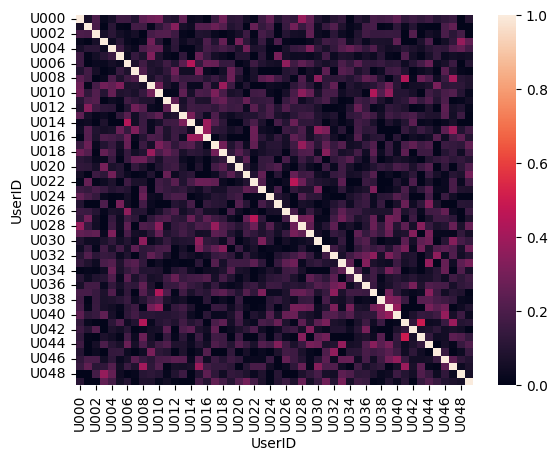

In [21]:
# Compute cosine similarity
from sklearn.metrics.pairwise import cosine_similarity
from seaborn import heatmap

similarity_matrix = cosine_similarity(user_item_matrix)
similarity_df = pd.DataFrame(similarity_matrix, index=user_item_matrix.index, columns=user_item_matrix.index)
print(similarity_df.head())

heatmap(similarity_df)


In [22]:
def recommend_products(target_user, user_item_matrix, similarity_df, top_n_users=5, top_n_products=5):
    # 1. Get top n similar users (excluding the user themselves)
    similar_users = similarity_df[target_user].sort_values(ascending=False)[1:top_n_users+1].index
    
    # 2. Get products the target user hasn't rated yet (value is 0)
    target_user_ratings = user_item_matrix.loc[target_user]
    unrated_products = target_user_ratings[target_user_ratings == 0].index
    
    # 3. Calculate weighted average scores for unrated products
    product_scores = {}
    for product in unrated_products:
        weights = 0
        score = 0
        for sim_user in similar_users:
            # Check if the similar user has rated this product
            sim_rating = user_item_matrix.loc[sim_user, product]
            if sim_rating > 0:
                similarity = similarity_df.loc[target_user, sim_user]
                score += similarity * sim_rating
                weights += similarity
        
        if weights > 0:
            product_scores[product] = score / weights
        else:
            product_scores[product] = 0
            
    # 4. Sort and return the top N recommendations
    recommendations = sorted(product_scores.items(), key=lambda x: x[1], reverse=True)[:top_n_products]
    return recommendations

# Example usage for User U000
recs = recommend_products('U000', user_item_matrix, similarity_df)
print(f"Top recommendations for U000: {recs}")

Top recommendations for U000: [('P0029', np.float64(5.0)), ('P0030', np.float64(5.0)), ('P0032', np.float64(5.0)), ('P0041', np.float64(5.0)), ('P0062', np.float64(5.0))]


In [23]:
# Implement evaluation metrics
from sklearn.metrics import precision_score

# Simplified Precision@K check
# See if the recommended products' categories match the user's top categories
def evaluate_recs(target_user, recommendations, user_data, product_data):
    user_fav_categories = user_data[user_data['UserID'] == target_user]['Category'].unique()
    
    hits = 0
    for prod_id, score in recommendations:
        category = product_data[product_data['ProductID'] == prod_id]['Category'].values[0]
        if category in user_fav_categories:
            hits += 1
            
    precision_at_k = hits / len(recommendations) if recommendations else 0
    return precision_at_k

print(f"Precision@5 for U000: {evaluate_recs('U000', recs, user_data, product_data)}")


Precision@5 for U000: 0.8
